# Day 2 – Calculus + Optimization
### 20-Day ML Revision Planner | Phase: Mathematical Foundation

**Topics covered:**
1. Functions and Derivatives
2. Partial Derivatives
3. Gradients
4. Chain Rule
5. Optimization & Gradient Descent
6. Learning Rate
7. Batch vs Stochastic vs Mini-batch Gradient Descent
8. Coding: Linear Regression + Gradient Descent from Scratch
9. Interview Questions
10. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)
print("NumPy version:", np.__version__)


NumPy version: 2.4.4


## 1. Functions and Derivatives

### What?
A **function** $f(x)$ maps an input to an output. The **derivative** $f'(x)$ (or $\frac{df}{dx}$) measures the *instantaneous rate of change* of $f$ with respect to $x$ — geometrically, the slope of the tangent line at a point.

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

### Why?
In ML, we almost always want to **minimize a loss function** $J(\theta)$ with respect to parameters $\theta$. The derivative tells us:
- Which direction increases/decreases the function
- How steep the function is at the current point

### How?
- If $f'(x) > 0$: function is increasing at $x$.
- If $f'(x) < 0$: function is decreasing at $x$.
- If $f'(x) = 0$: $x$ is a critical point (possible minimum, maximum, or saddle point).

### Common derivative rules
| Function | Derivative |
|---|---|
| $x^n$ | $n x^{n-1}$ |
| $e^x$ | $e^x$ |
| $\ln(x)$ | $1/x$ |
| $c$ (constant) | $0$ |
| $f(x) + g(x)$ | $f'(x) + g'(x)$ |


Numerical derivative of x^2 at x=3.0: 6.000000
Analytical derivative (2x) at x=3.0: 6.0


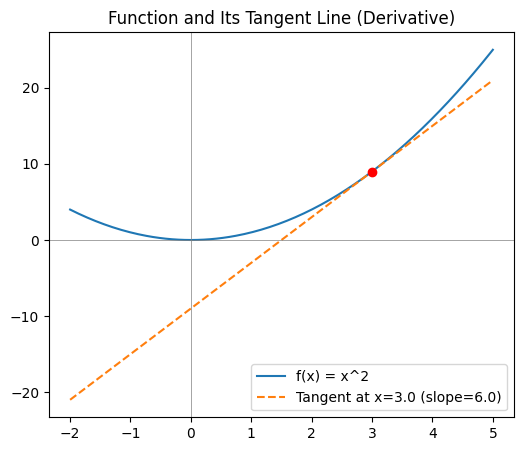

In [2]:
# Numerical derivative (finite difference approximation)
def numerical_derivative(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

def f(x):
    return x**2  # f(x) = x^2, true derivative f'(x) = 2x

x_val = 3.0
approx = numerical_derivative(f, x_val)
true_val = 2 * x_val
print(f"Numerical derivative of x^2 at x={x_val}: {approx:.6f}")
print(f"Analytical derivative (2x) at x={x_val}: {true_val}")

# Visualize function and tangent line
x = np.linspace(-2, 5, 200)
y = x**2
slope = numerical_derivative(f, x_val)
tangent = slope * (x - x_val) + f(x_val)

plt.figure(figsize=(6, 5))
plt.plot(x, y, label="f(x) = x^2")
plt.plot(x, tangent, '--', label=f"Tangent at x={x_val} (slope={slope:.1f})")
plt.scatter([x_val], [f(x_val)], color='red', zorder=5)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.legend(); plt.title("Function and Its Tangent Line (Derivative)")
plt.show()


## 2. Partial Derivatives

### What?
When a function depends on **multiple variables**, e.g. $f(x, y)$, the **partial derivative** measures the rate of change with respect to *one* variable while holding all others constant.

$$\frac{\partial f}{\partial x}, \quad \frac{\partial f}{\partial y}$$

### Why?
ML loss functions depend on **many parameters at once** (weights $w_1, w_2, \dots, w_n$, bias $b$). We need to know how the loss changes with respect to *each* parameter individually — that's exactly what a partial derivative gives us.

### How?
Treat every other variable as a constant, then differentiate normally with respect to the variable of interest.

### Example
For $f(x, y) = x^2 + 3xy + y^2$:
- $\frac{\partial f}{\partial x} = 2x + 3y$
- $\frac{\partial f}{\partial y} = 3x + 2y$


In [3]:
# Numerical partial derivatives
def f_xy(x, y):
    return x**2 + 3*x*y + y**2

def partial_x(f, x, y, h=1e-6):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-6):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

x0, y0 = 2.0, 1.0
df_dx = partial_x(f_xy, x0, y0)
df_dy = partial_y(f_xy, x0, y0)

print(f"Numerical df/dx at ({x0},{y0}): {df_dx:.4f}  | Analytical (2x+3y): {2*x0 + 3*y0}")
print(f"Numerical df/dy at ({x0},{y0}): {df_dy:.4f}  | Analytical (3x+2y): {3*x0 + 2*y0}")


Numerical df/dx at (2.0,1.0): 7.0000  | Analytical (2x+3y): 7.0
Numerical df/dy at (2.0,1.0): 8.0000  | Analytical (3x+2y): 8.0


## 3. Gradients

### What?
The **gradient** $\nabla f$ of a multivariable function is a **vector** containing all its partial derivatives:

$$\nabla f(x, y) = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

For a loss function $J(\theta)$ with parameters $\theta = [\theta_1, \dots, \theta_n]$:

$$\nabla J(\theta) = \begin{bmatrix} \frac{\partial J}{\partial \theta_1} \\ \vdots \\ \frac{\partial J}{\partial \theta_n} \end{bmatrix}$$

### Why?
The gradient **always points in the direction of steepest ascent** (fastest increase) of the function. To *minimize* a loss, we move in the **opposite** direction of the gradient — this is the core idea behind gradient descent.

### How?
Compute the partial derivative with respect to every parameter, stack them into a vector. The magnitude of the gradient tells you how steep the loss surface is at that point; the direction tells you which way is "uphill."

### ML Connection
Loss → derivative → gradient → parameter update. This chain is the beating heart of virtually every model training loop, from linear regression to deep neural networks.


Gradient of f(x,y)=x^2+y^2 at (2.0, 1.5): [4. 3.]
--> Points 'uphill'; moving in -gradient direction decreases f fastest.


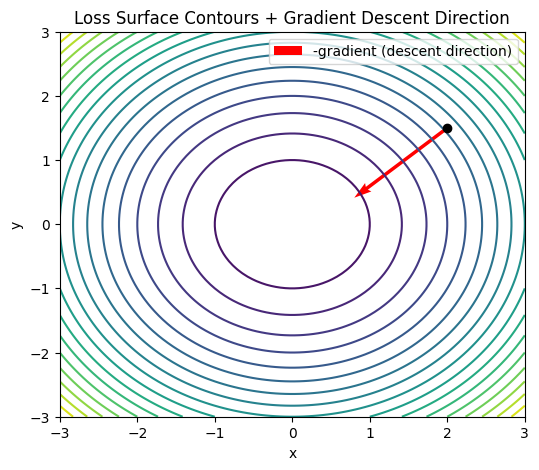

In [4]:
# Compute and visualize the gradient of f(x,y) = x^2 + y^2 (a bowl-shaped loss surface)
def bowl(x, y):
    return x**2 + y**2

def gradient(f, x, y, h=1e-6):
    return np.array([partial_x(f, x, y, h), partial_y(f, x, y, h)])

point = (2.0, 1.5)
grad = gradient(bowl, *point)
print(f"Gradient of f(x,y)=x^2+y^2 at {point}: {grad}")
print("--> Points 'uphill'; moving in -gradient direction decreases f fastest.")

# Contour plot with gradient vector
x_range = np.linspace(-3, 3, 100)
y_range = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

plt.figure(figsize=(6, 5))
plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.quiver(point[0], point[1], -grad[0], -grad[1], color='red', scale=20, label='-gradient (descent direction)')
plt.scatter([point[0]], [point[1]], color='black', zorder=5)
plt.title("Loss Surface Contours + Gradient Descent Direction")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.show()


## 4. Chain Rule

### What?
The chain rule lets us differentiate a **composition of functions**: if $y = f(u)$ and $u = g(x)$, then

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

### Why?
ML models — especially neural networks — are compositions of many nested functions (layers). The chain rule is what makes **backpropagation** possible: it lets us compute how the final loss changes with respect to *every* weight in *every* layer, by chaining local derivatives together.

### How?
Break a complex function into simpler nested steps, differentiate each step locally, then multiply the local derivatives together along the path from output back to input.

### Example
$y = (3x + 1)^2$. Let $u = 3x+1$, so $y = u^2$.
- $\frac{dy}{du} = 2u$
- $\frac{du}{dx} = 3$
- $\frac{dy}{dx} = 2u \cdot 3 = 6(3x+1)$


In [5]:
# Verify the chain rule numerically
def y_of_x(x):
    return (3*x + 1)**2

x_val = 2.0
numerical = numerical_derivative(y_of_x, x_val)

u = 3*x_val + 1
analytical = 6 * (3*x_val + 1)   # derived via chain rule above

print(f"Numerical dy/dx at x={x_val}: {numerical:.4f}")
print(f"Chain-rule analytical dy/dx at x={x_val}: {analytical:.4f}")

# A tiny 2-step "computational graph" example, similar to a mini neural net
# z = w*x + b  (linear step)
# a = z^2      (nonlinear step, like a squared-error term)
# We want da/dw using the chain rule: da/dw = da/dz * dz/dw

w, x_in, b = 2.0, 3.0, 1.0
z = w * x_in + b
a = z**2

dz_dw = x_in          # dz/dw = x
da_dz = 2 * z          # da/dz = 2z
da_dw_chain = da_dz * dz_dw

print(f"\nz = w*x + b = {z}")
print(f"a = z^2 = {a}")
print(f"da/dw via chain rule = da/dz * dz/dw = {da_dz} * {dz_dw} = {da_dw_chain}")


Numerical dy/dx at x=2.0: 42.0000
Chain-rule analytical dy/dx at x=2.0: 42.0000

z = w*x + b = 7.0
a = z^2 = 49.0
da/dw via chain rule = da/dz * dz/dw = 14.0 * 3.0 = 42.0


## 5. Optimization & Gradient Descent

### What?
**Optimization** is the process of finding parameter values that minimize (or maximize) a function — in ML, minimizing a **loss/cost function** $J(\theta)$.

**Gradient Descent** is an iterative optimization algorithm:

$$\theta_{new} = \theta_{old} - \alpha \nabla J(\theta)$$

where $\alpha$ is the **learning rate**.

### Why?
Most ML models don't have a simple closed-form solution for their optimal parameters (or the closed form, like the Normal Equation, doesn't scale to large datasets). Gradient descent gives a general, scalable way to find good parameters by repeatedly nudging them "downhill."

### How?
1. Initialize parameters $\theta$ (often randomly or at zero).
2. Compute the gradient of the loss with respect to $\theta$.
3. Update: $\theta \leftarrow \theta - \alpha \nabla J(\theta)$.
4. Repeat until convergence (loss stops decreasing meaningfully) or a max number of iterations.

### Learning Rate ($\alpha$)
- **Too large** → overshoots the minimum, may diverge (loss oscillates or explodes).
- **Too small** → converges very slowly, may get stuck before reaching a good solution within a reasonable number of iterations.
- **Just right** → smooth, efficient convergence.


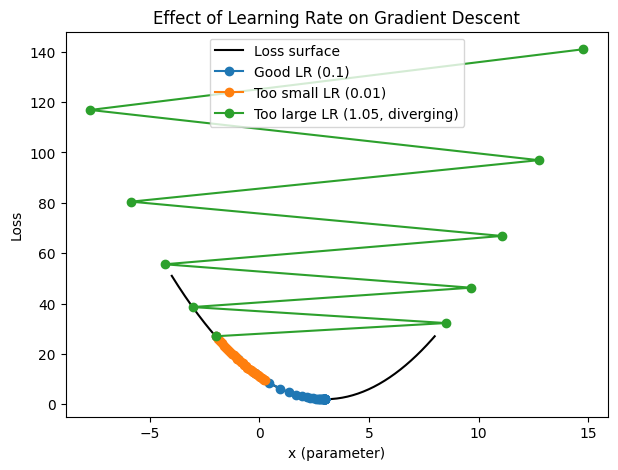

Good LR final x: 2.9938 (true minimum is x=3)
Too-small LR final x after 30 iters: 0.2726 -- still far from 3
Too-large LR trajectory (first 10 steps): [-2, 8.5, -3.05, 9.66, -4.32, 11.05, -5.86, 12.74, -7.72, 14.79] -- diverging!


In [6]:
# Visualize gradient descent on a simple 1D function: f(x) = (x - 3)^2 + 2
def loss_1d(x):
    return (x - 3)**2 + 2

def grad_1d(x):
    return 2 * (x - 3)   # derivative of (x-3)^2 + 2

def run_gd_1d(start_x, lr, n_iters=30):
    x = start_x
    history = [x]
    for _ in range(n_iters):
        x = x - lr * grad_1d(x)
        history.append(x)
    return history

good_lr = run_gd_1d(start_x=-2, lr=0.1)
too_small_lr = run_gd_1d(start_x=-2, lr=0.01)
too_large_lr = run_gd_1d(start_x=-2, lr=1.05)

x_plot = np.linspace(-4, 8, 200)
plt.figure(figsize=(7, 5))
plt.plot(x_plot, loss_1d(x_plot), color='black', label='Loss surface')
plt.plot(good_lr, [loss_1d(v) for v in good_lr], 'o-', label='Good LR (0.1)')
plt.plot(too_small_lr, [loss_1d(v) for v in too_small_lr], 'o-', label='Too small LR (0.01)')
plt.plot(too_large_lr[:10], [loss_1d(v) for v in too_large_lr[:10]], 'o-', label='Too large LR (1.05, diverging)')
plt.legend(); plt.title("Effect of Learning Rate on Gradient Descent")
plt.xlabel("x (parameter)"); plt.ylabel("Loss")
plt.show()

print("Good LR final x:", round(good_lr[-1], 4), "(true minimum is x=3)")
print("Too-small LR final x after 30 iters:", round(too_small_lr[-1], 4), "-- still far from 3")
print("Too-large LR trajectory (first 10 steps):", [round(v, 2) for v in too_large_lr[:10]], "-- diverging!")


## 6. Batch, Stochastic, and Mini-Batch Gradient Descent

### What?
These are three variants of gradient descent that differ in **how much data** is used to compute the gradient at each update step:

| Variant | Data used per update | Characteristics |
|---|---|---|
| **Batch GD** | Entire dataset | Stable, accurate gradient; slow per step, high memory for large data |
| **Stochastic GD (SGD)** | One random sample | Very fast per step, noisy updates, can escape shallow local minima |
| **Mini-batch GD** | Small batch (e.g., 32–256 samples) | Balance of speed and stability; standard in practice (esp. deep learning) |

### Why?
- Batch GD is precise but computationally expensive/impossible for huge datasets (can't fit in memory, slow per epoch).
- SGD is fast and scalable but the noisy gradient causes the loss to oscillate.
- Mini-batch GD is the practical default: leverages vectorized operations efficiently and smooths out noise compared to pure SGD.

### How?
The only thing that changes across variants is **how many rows of $X$ and $y$** are used to compute the gradient before each parameter update.


True parameters: bias=4, slope=3
Batch GD result:      [3.8481 3.0652]
SGD result:            [3.9754 2.9524]
Mini-batch GD result:  [4.0725 2.8983]


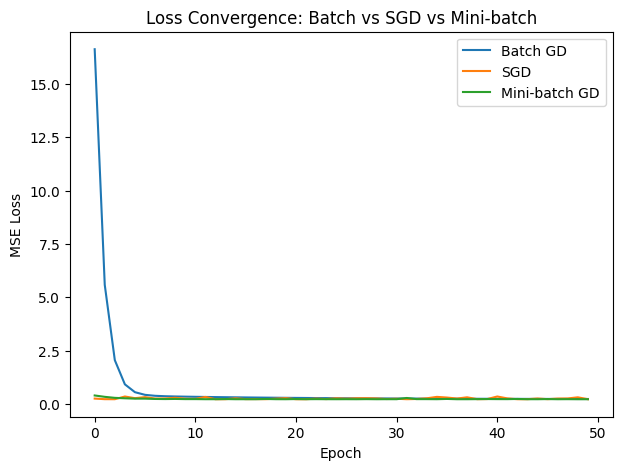

In [7]:
# Compare Batch, Stochastic, and Mini-batch GD on a linear regression toy problem
np.random.seed(0)
n_samples = 200
X_data = 2 * np.random.rand(n_samples, 1)
y_data = 4 + 3 * X_data + np.random.randn(n_samples, 1) * 0.5   # y = 4 + 3x + noise

X_b = np.hstack([np.ones((n_samples, 1)), X_data])   # add bias column

def compute_gradient(X_batch, y_batch, theta):
    m = len(X_batch)
    predictions = X_batch @ theta
    error = predictions - y_batch
    return (2/m) * X_batch.T @ error

def gradient_descent_variant(X_b, y, lr=0.1, n_epochs=50, batch_size=None):
    m = len(X_b)
    theta = np.zeros((2, 1))
    loss_history = []
    for epoch in range(n_epochs):
        if batch_size is None:  # Batch GD: use all data
            grad = compute_gradient(X_b, y, theta)
            theta = theta - lr * grad
        elif batch_size == 1:  # SGD: one random sample at a time
            indices = np.random.permutation(m)
            for i in indices:
                xi = X_b[i:i+1]
                yi = y[i:i+1]
                grad = compute_gradient(xi, yi, theta)
                theta = theta - lr * grad
        else:  # Mini-batch GD
            indices = np.random.permutation(m)
            for start in range(0, m, batch_size):
                batch_idx = indices[start:start+batch_size]
                grad = compute_gradient(X_b[batch_idx], y[batch_idx], theta)
                theta = theta - lr * grad
        preds = X_b @ theta
        mse = np.mean((preds - y) ** 2)
        loss_history.append(mse)
    return theta, loss_history

theta_batch, loss_batch = gradient_descent_variant(X_b, y_data, lr=0.1, n_epochs=50, batch_size=None)
theta_sgd, loss_sgd = gradient_descent_variant(X_b, y_data, lr=0.05, n_epochs=50, batch_size=1)
theta_mini, loss_mini = gradient_descent_variant(X_b, y_data, lr=0.1, n_epochs=50, batch_size=32)

print("True parameters: bias=4, slope=3")
print("Batch GD result:     ", theta_batch.ravel())
print("SGD result:           ", theta_sgd.ravel())
print("Mini-batch GD result: ", theta_mini.ravel())

plt.figure(figsize=(7, 5))
plt.plot(loss_batch, label="Batch GD")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_mini, label="Mini-batch GD")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Loss Convergence: Batch vs SGD vs Mini-batch")
plt.legend()
plt.show()


## 7. Coding Practice — Linear Regression + Gradient Descent From Scratch

**Goal:** Implement a complete linear regression model trained with batch gradient descent, entirely from scratch (no scikit-learn), then verify against the analytical Normal Equation.

Cost function (Mean Squared Error):
$$J(\theta) = \frac{1}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2, \quad h_\theta(x) = \theta^T x$$

Gradient of the cost function:
$$\nabla J(\theta) = \frac{2}{m} X^T (X\theta - y)$$


In [8]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.loss_history = []

    def _add_bias(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        X_b = self._add_bias(X)
        m, n = X_b.shape
        self.theta = np.zeros((n, 1))

        for i in range(self.n_iterations):
            predictions = X_b @ self.theta
            error = predictions - y
            gradient = (2 / m) * X_b.T @ error
            self.theta = self.theta - self.lr * gradient

            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        X_b = self._add_bias(X)
        return X_b @ self.theta


# Train on our toy dataset
model = LinearRegressionScratch(learning_rate=0.1, n_iterations=200)
model.fit(X_data, y_data)

print("Learned parameters (bias, slope):", model.theta.ravel())
print("True parameters were: bias=4, slope=3")

# Compare against the analytical Normal Equation solution from Day 1
X_b_full = np.hstack([np.ones((n_samples, 1)), X_data])
theta_normal_eq = np.linalg.inv(X_b_full.T @ X_b_full) @ X_b_full.T @ y_data
print("Normal Equation parameters:      ", theta_normal_eq.ravel())
print("--> Gradient descent converges to (almost) the same solution as the closed-form Normal Equation.")


Learned parameters (bias, slope): [4.0512 2.8924]
True parameters were: bias=4, slope=3
Normal Equation parameters:       [4.0535 2.8905]
--> Gradient descent converges to (almost) the same solution as the closed-form Normal Equation.


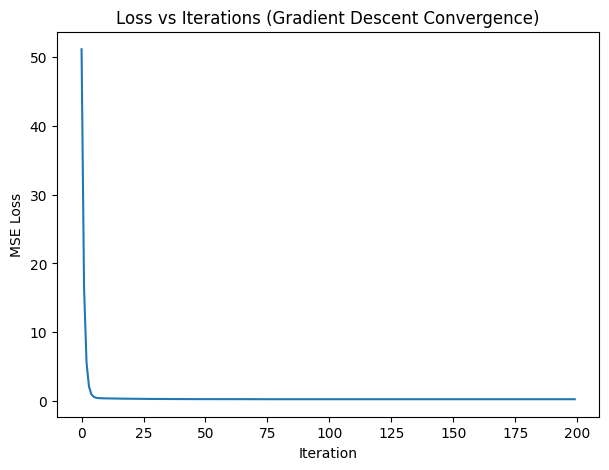

Final loss: 0.2282673904505018
Loss after 10 iterations: 0.35695653627312174
--> Loss decreases sharply at first, then flattens as it converges (classic GD behavior).


In [9]:
# Plot loss vs iterations (convergence curve) — required daily output
plt.figure(figsize=(7, 5))
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Loss vs Iterations (Gradient Descent Convergence)")
plt.show()

print("Final loss:", model.loss_history[-1])
print("Loss after 10 iterations:", model.loss_history[9])
print("--> Loss decreases sharply at first, then flattens as it converges (classic GD behavior).")


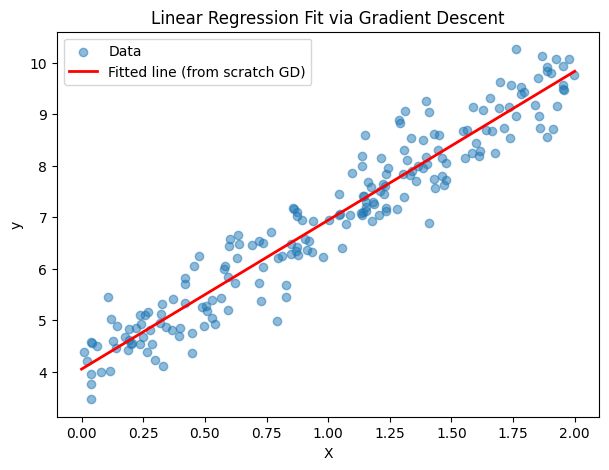

In [10]:
# Visualize the fitted regression line against the data
plt.figure(figsize=(7, 5))
plt.scatter(X_data, y_data, alpha=0.5, label="Data")
x_line = np.array([[0], [2]])
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label="Fitted line (from scratch GD)")
plt.xlabel("X"); plt.ylabel("y")
plt.title("Linear Regression Fit via Gradient Descent")
plt.legend()
plt.show()


In [11]:
# Debug exercise: what happens with a learning rate that's too high?
model_diverge = LinearRegressionScratch(learning_rate=1.5, n_iterations=20)
model_diverge.fit(X_data, y_data)
print("Loss history with LR=1.5 (too high):", [round(l, 2) for l in model_diverge.loss_history])
print("--> Notice the loss exploding/oscillating instead of decreasing. This is a common debugging")
print("    scenario in interviews: 'my loss is NaN/exploding' almost always means the learning rate is too large.")


Loss history with LR=1.5 (too high): [np.float64(51.18), np.float64(1550.53), np.float64(47373.96), np.float64(1447692.46), np.float64(44239991.51), np.float64(1351928811.09), np.float64(41313559447.4), np.float64(1262500052132.91), np.float64(38580708197591.86), np.float64(1178986917674428.2), np.float64(3.602863236539075e+16), np.float64(1.1009980947718508e+18), np.float64(3.3645373834830512e+19), np.float64(1.0281681556588644e+21), np.float64(3.141976550774966e+22), np.float64(9.601558452560354e+23), np.float64(2.9341378978526956e+25), np.float64(8.966424821711836e+26), np.float64(2.7400475670297345e+28), np.float64(8.373304654722121e+29)]
--> Notice the loss exploding/oscillating instead of decreasing. This is a common debugging
    scenario in interviews: 'my loss is NaN/exploding' almost always means the learning rate is too large.


## 8. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What is a gradient?**
   *Hint: vector of partial derivatives; points in direction of steepest ascent.*

2. **What happens if the learning rate is too large? Too small?**
   *Hint: too large → divergence/oscillation; too small → slow convergence, may not reach minimum in time.*

3. **Batch GD vs SGD vs Mini-batch GD — what are the trade-offs?**
   *Hint: think about gradient accuracy, computation speed per step, memory, and noise (ability to escape local minima).*

4. **(Bonus) Why does the chain rule matter for training neural networks?**
   *Hint: it's the mathematical basis for backpropagation — computing gradients through many nested layers.*

5. **(Bonus) How would you detect that gradient descent is diverging while training a real model?**
   *Hint: loss increasing or becoming NaN/Inf over iterations; plotting the loss curve is the standard diagnostic.*


## 9. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain what a derivative represents geometrically and why it matters for optimization.
- [ ] Compute a partial derivative by hand for a simple 2-variable function.
- [ ] Explain what a gradient is and why moving in $-\nabla J(\theta)$ minimizes a function.
- [ ] State and apply the chain rule to a simple composed function.
- [ ] Write the gradient descent update rule from memory: $\theta_{new} = \theta_{old} - \alpha \nabla J(\theta)$.
- [ ] Explain the effect of learning rate being too large/too small, with the visual intuition.
- [ ] Explain the difference between Batch GD, SGD, and Mini-batch GD, and when you'd choose each.
- [ ] Implement linear regression + gradient descent from scratch without looking at reference code.

### 📌 Daily Output (per the planner)
A **working gradient-descent implementation** (Section 7 above) — able to:
- Fit a linear regression model from scratch
- Match (approximately) the analytical Normal Equation solution
- Plot and interpret the loss-vs-iterations convergence curve

Close this notebook and re-implement `LinearRegressionScratch` from memory in a blank file — that's the real test of Day 2 mastery.
